# Recurrent neural networks
In this notebook, we will implement a simple, "Elman" recurrent neural network. It is a multi-layer perceptron, in which the hidden layer does not only have incoming connections from the inputs, but also from the hidden neurons of the previous time step. 

This is captured by the following formulas:

$\mathbf{h}_t = f(W_{ih} \mathbf{x}_t + \mathbf{b}_h + W_{hh} \mathbf{h}_{t-1} )$

$\mathbf{o}_t = g(W_{ho} \mathbf{h}_t + \mathbf{b}_o)$

, where $\mathbf{x}_t$ are the inputs at time $t$, and $\mathbf{h}_t$ the hidden outputs at time step $t$. The weight matrices have subscripts indicating which layers are connected to each other. 


The Elman RNN can be illustrated as follows:

<IMG SRC="Elman.png"></IMG>

Whereas a standard feedforward neural network implements a function from inputs to outputs, the recurrence in the hidden layer allows the network to retain a memory of previous inputs. Hence, given the same input $\mathbf{x}$, it may give a different output, dependent on the hidden state $\mathbf{h}_t$. 


## Time series prediction

Here, you will implement a simple RNN and apply it to a time series prediction task. We use the air passenger data from <A HREF="https://www.kaggle.com/datasets/ashfakyeafi/air-passenger-data-for-time-series-analysis">Kaggle</A>. It contains the number of passengers per month for a period of 144 months from the end of the 1940s to 1960. If you have a local copy of this repository, please download the dataset into this folder. Else, you the script below will load a dummy dataset that roughly shows the same trend. 

<span style="color:red;"><B>Exercise 1:</B></span>
1. First run the cell below to load the data. Inspect the data. Is there anything that may form a problem for learning?


In [ ]:
import time_series_prediction
import torch
import numpy as np
from matplotlib import pyplot as plt

month, passengers, input_tensor, target_tensor = time_series_prediction.get_data_set()

plt.figure()
plt.plot(month, passengers)
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.show()


2. Implement a class for the simple Elman RNN. We already made the skeleton code below:

In [ ]:
class ElmanRNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ElmanRNN, self).__init__()
        self.hidden_size = hidden_size
        # Implement

    def forward(self, input, hidden):
        # Implement
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

3. Train the neural network on the entire time series and see whether it successfully learns the prediction task:

In [ ]:
# Implement a training loop:



4. Evaluate the RNN to compare the predictions to the targets. Do you think it has learned the pattern in the data successfully? Would you know of a way to check this?

In [ ]:
rnn.eval()
predictions = []
hidden = rnn.initHidden()
for i in range(input_tensor.size(0)):
    with torch.no_grad():
        output, hidden = rnn(input_tensor[i].unsqueeze(0), hidden)
        predictions.append(output.item())

# Plot the results
plt.figure()
plt.plot(month[1:], passengers[1:], label='Actual')
plt.plot(month[1:], predictions, label='Predicted')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.title('Air Passengers Prediction using Elman RNN')
plt.legend()
plt.show()

5. One way to check what the network learns is to train on the first part of the series, and then test it on the second part of the series. Can you retrain the network, but now only on the first 40% of the data? How well does it predict the remaining 60%?

In [ ]:
# Implement training on 40% of the data:
# ...

rnn.eval()
predictions = []
hidden = rnn.initHidden()
for i in range(input_tensor.size(0)):
    with torch.no_grad():
        output, hidden = rnn(input_tensor[i].unsqueeze(0), hidden)
        predictions.append(output.item())

# Plot the results
plt.figure()
plt.plot(month[1:], passengers[1:]/100.0, label='Actual')
plt.plot(month[1:], predictions, label='Predicted')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.title('Air Passengers Prediction using Elman RNN')
plt.legend()
plt.show()

## Answers

1. The months go from 0 to 143, while the number of passengers is in the order of a few hundreds (depending on the real or dummy data). In principle, this relation seems reasonable. However, we got much better results by normalizing the number of passengers, dividing it by a 100:

File 'AirPassengers.csv' found. Using real dataset.


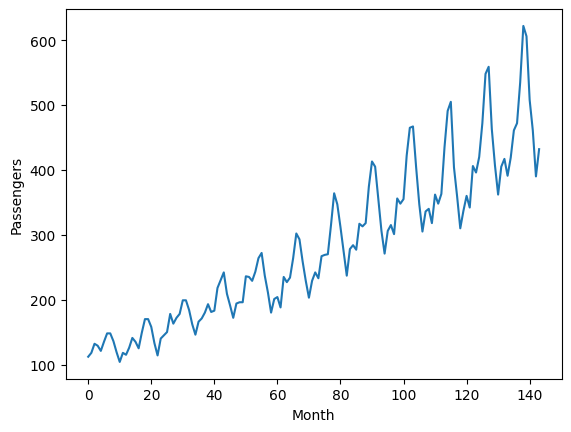

In [1]:
import time_series_prediction
import torch
import numpy as np
from matplotlib import pyplot as plt

month, passengers, input_tensor, target_tensor = time_series_prediction.get_data_set()

plt.figure()
plt.plot(month, passengers)
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.show()

passenger_factor = 100.0
input_tensor /= passenger_factor
target_tensor /= passenger_factor

2. The Elman network is relatively straightforward to implement. It just requires concatenating the inputs and hiddens in the forward pass, as inputs to a Linear layer:

In [2]:
class ElmanRNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ElmanRNN, self).__init__()
        self.hidden_size = hidden_size
        self.i2h = torch.nn.Linear(input_size + hidden_size, hidden_size)
        self.h2o = torch.nn.Linear(hidden_size, output_size)
        self.activation = torch.nn.Tanh()

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        hidden = self.activation(self.i2h(combined))
        output = self.h2o(hidden)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

3. For the training, it is important to reset the hiddens every epoch, and reset the gradients to zero. We immediately define a variable `ratio` which determines on how large a part the RNN learns.

In [3]:
def train(rnn, criterion, optimizer, input_tensor, target_tensor, n_epochs=1000):
    outputs_list = []  # Store outputs for correlation calculation
    targets_list = []  # Store targets for correlation calculation
    
    for epoch in range(n_epochs):
        # Reset the hiddens to zero, and resetting the tracking of the gradient.
        # This is important to make sure that backpropagation through time stops at the start of the sequence.
        hidden = rnn.initHidden()
        rnn.zero_grad()
        
        outputs_list.clear()
        targets_list.clear()
        
        # Forward pass - collect all outputs
        for i in range(input_tensor.size(0)):
            output, hidden = rnn(input_tensor[i].unsqueeze(0), hidden)
            outputs_list.append(output)
            targets_list.append(target_tensor[i].unsqueeze(0))
        
        # Calculate loss based on all outputs vs targets
        all_outputs = torch.cat(outputs_list, dim=0)
        all_targets = torch.cat(targets_list, dim=0)
        loss = criterion(all_outputs, all_targets)

        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item()}')
    
    return rnn

criterion = torch.nn.MSELoss()
input_size = 1
hidden_size = 10
output_size = 1
rnn = ElmanRNN(input_size, hidden_size, output_size)
optimizer = torch.optim.Adam(rnn.parameters(), lr=0.01)

# Prepare the data for training
#month, passengers, input_tensor, target_tensor = get_data_set()
ratio = 1.0
rnn = train(rnn, criterion, optimizer, input_tensor[:int(ratio * len(input_tensor))], target_tensor[:int(ratio * len(target_tensor))], n_epochs=1000)

Epoch 0, Loss: 8.489533424377441
Epoch 100, Loss: 0.18831659853458405
Epoch 200, Loss: 0.12483951449394226
Epoch 300, Loss: 0.10558045655488968
Epoch 400, Loss: 0.09553678333759308
Epoch 500, Loss: 0.08526970446109772
Epoch 600, Loss: 0.08513982594013214
Epoch 700, Loss: 0.07493007183074951
Epoch 800, Loss: 0.06534096598625183
Epoch 900, Loss: 0.0596749484539032


4. In the prediction, we show the number of passengers divided by a 100 as well:

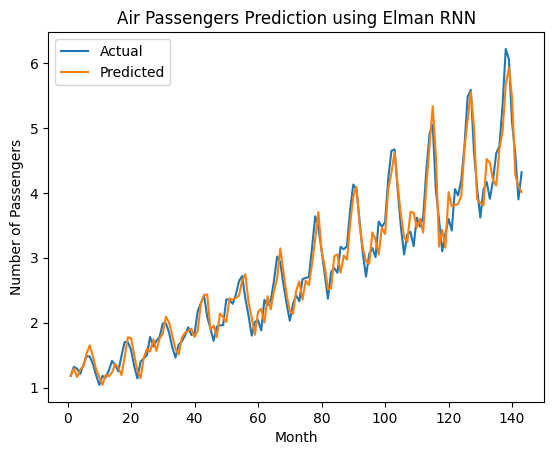

In [4]:
rnn.eval()
predictions = []
hidden = rnn.initHidden()
for i in range(input_tensor.size(0)):
    with torch.no_grad():
        output, hidden = rnn(input_tensor[i].unsqueeze(0), hidden)
        predictions.append(output.item())

# Plot the results
plt.figure()
plt.plot(month[1:], passengers[1:]/passenger_factor, label='Actual')
plt.plot(month[1:], predictions, label='Predicted')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.title('Air Passengers Prediction using Elman RNN')
plt.legend()
plt.show()

5. If we train the RNN on part of the data (like 40%), it often learns to generalize beyond, but never captures the increasing amplitude of the variation over the year. Sometimes it actually just flatlines after the learned part.

Epoch 0, Loss: 5.001328468322754
Epoch 100, Loss: 0.07835095375776291
Epoch 200, Loss: 0.03812588378787041
Epoch 300, Loss: 0.029481424018740654
Epoch 400, Loss: 0.0274768378585577
Epoch 500, Loss: 0.02467023953795433
Epoch 600, Loss: 0.022850017994642258
Epoch 700, Loss: 0.021561315283179283
Epoch 800, Loss: 0.026958974078297615
Epoch 900, Loss: 0.020248059183359146


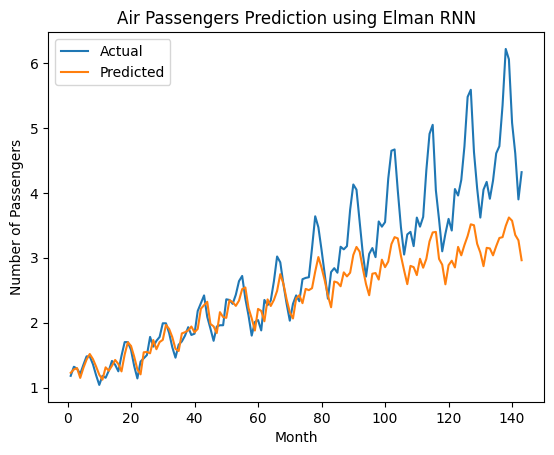

In [7]:
def train(rnn, criterion, optimizer, input_tensor, target_tensor, n_epochs=1000):
    outputs_list = []  # Store outputs for correlation calculation
    targets_list = []  # Store targets for correlation calculation
    
    for epoch in range(n_epochs):
        hidden = rnn.initHidden()
        rnn.zero_grad()
        
        outputs_list.clear()
        targets_list.clear()
        
        # Forward pass - collect all outputs
        for i in range(input_tensor.size(0)):
            output, hidden = rnn(input_tensor[i].unsqueeze(0), hidden)
            outputs_list.append(output)
            targets_list.append(target_tensor[i].unsqueeze(0))
        
        # Calculate loss based on all outputs vs targets
        all_outputs = torch.cat(outputs_list, dim=0)
        all_targets = torch.cat(targets_list, dim=0)
        loss = criterion(all_outputs, all_targets)

        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item()}')
    
    return rnn

criterion = torch.nn.MSELoss()
input_size = 1
hidden_size = 10
output_size = 1
rnn = ElmanRNN(input_size, hidden_size, output_size)
optimizer = torch.optim.Adam(rnn.parameters(), lr=0.01)

# Prepare the data for training
#month, passengers, input_tensor, target_tensor = get_data_set()
ratio = 0.4
rnn = train(rnn, criterion, optimizer, input_tensor[:int(ratio * len(input_tensor))], target_tensor[:int(ratio * len(target_tensor))], n_epochs=1000)

rnn.eval()
predictions = []
hidden = rnn.initHidden()
for i in range(input_tensor.size(0)):
    with torch.no_grad():
        output, hidden = rnn(input_tensor[i].unsqueeze(0), hidden)
        predictions.append(output.item())

# Plot the results
plt.figure()
plt.plot(month[1:], passengers[1:]/passenger_factor, label='Actual')
plt.plot(month[1:], predictions, label='Predicted')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.title('Air Passengers Prediction using Elman RNN')
plt.legend()
plt.show()